#### SECTION 1.1: IMPORT LIBRARIES

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', None)

#### SECTION 1.2: LOAD RAW DATA (WITH CORRECT COLUMN NAMES)

In [12]:
import pandas as pd
import numpy as np
import os

data_raw = r"D:\DevProjects\Python\AL2002-PROJECT\data\raw"

# Load events - skip first row (header)
events = pd.read_csv(os.path.join(data_raw, 'events.csv'),
                     skiprows=1,
                     names=['timestamp', 'visitorid', 'event', 'itemid', 'transactionid'])

# Load category tree - skip first row
cat_tree = pd.read_csv(os.path.join(data_raw, 'category_tree.csv'),
                       skiprows=1,
                       names=['categoryid', 'parentid'])

# Load item properties part1 - skip first row
item_props = pd.read_csv(os.path.join(data_raw, 'item_properties_part1.csv'),
                         skiprows=1,
                         names=['timestamp', 'itemid', 'property', 'value'])

print("Events shape:", events.shape)
print("Category tree shape:", cat_tree.shape)
print("Item properties (part1) shape:", item_props.shape)

Events shape: (2756101, 5)
Category tree shape: (1669, 2)
Item properties (part1) shape: (10999999, 4)


#### SECTION 1.3: INSPECT FIRST FEW ROWS

In [13]:
print("Events - first 5 rows:")
print(events.head())
print("\nCategory tree - first 5 rows:")
print(cat_tree.head())
print("\nItem properties - first 5 rows:")
print(item_props.head())

Events - first 5 rows:
       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN

Category tree - first 5 rows:
   categoryid  parentid
0        1016     213.0
1         809     169.0
2         570       9.0
3        1691     885.0
4         536    1691.0

Item properties - first 5 rows:
       timestamp  itemid    property                            value
0  1435460400000  460429  categoryid                             1338
1  1441508400000  206783         888          1116713 960601 n277.200
2  1439089200000  395014         400  n552.000 639502 n720.000 424566
3  1431226800000   59481         790                       n15360.000
4  1431831600000  156781         917                           828513


#### SECTION 1.4: HANDLE MISSING VALUES

In [14]:
# Check missing values
print(events.isnull().sum())
print(cat_tree.isnull().sum())   # parentid may be null for root categories
print(item_props.isnull().sum())

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64
categoryid     0
parentid      25
dtype: int64
timestamp    0
itemid       0
property     0
value        0
dtype: int64


#### SECTION 1.5: CONVERT TIMESTAMP TO READABLE DATA

In [15]:
events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
print(events[['timestamp', 'datetime']].head())

       timestamp                datetime
0  1433221332117 2015-06-02 05:02:12.117
1  1433224214164 2015-06-02 05:50:14.164
2  1433221999827 2015-06-02 05:13:19.827
3  1433221955914 2015-06-02 05:12:35.914
4  1433221337106 2015-06-02 05:02:17.106


#### SECTION 1.6: FILTER ONLY USEFUL EVENTS

In [16]:
print("Unique events:", events['event'].unique())
# Usually: 'view', 'addtocart', 'transaction'
events = events[events['event'].isin(['view', 'addtocart', 'transaction'])]
print("After filtering:", events.shape)

Unique events: ['view' 'addtocart' 'transaction']
After filtering: (2756101, 6)


### SECTION 1.7: REDUCE DATASET SIZE

In [17]:
# Option A: Sample 500,000 random rows
events_sampled = events.sample(n=500000, random_state=42)

# Option B: Sample by visitor (keep whole sessions)
# visitors = events['visitorid'].drop_duplicates().sample(frac=0.2, random_state=42)
# events_sampled = events[events['visitorid'].isin(visitors)]

print("Sampled events shape:", events_sampled.shape)

Sampled events shape: (500000, 6)


#### SECTION 1.8: FUNDAMENTAL EXPLORATORY ANALYSIS

Unique visitors: 369575
Unique items: 121521
event
view           483190
addtocart       12720
transaction      4090
Name: count, dtype: int64


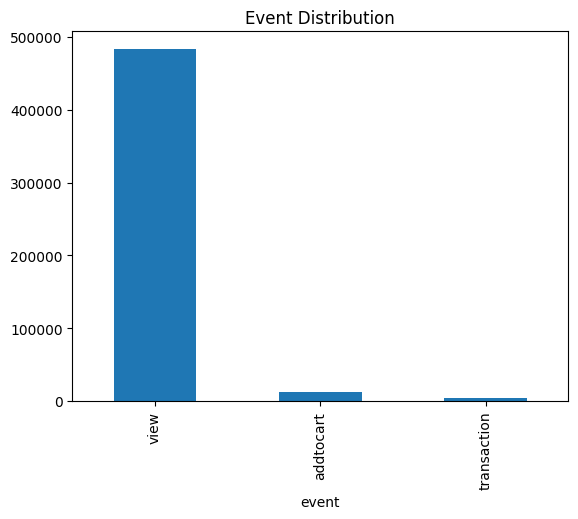

In [18]:
# Number of unique visitors, items
print("Unique visitors:", events_sampled['visitorid'].nunique())
print("Unique items:", events_sampled['itemid'].nunique())

# Event type distribution
print(events_sampled['event'].value_counts())

# Plot
events_sampled['event'].value_counts().plot(kind='bar')
plt.title("Event Distribution")
plt.show()

#### SECTION 1.9: SAVE CLEANED & SAMPLED DATA

In [19]:
processed_path = r"D:\DevProjects\Python\AL2002-PROJECT\data\processed"
os.makedirs(processed_path, exist_ok=True)

events_sampled.to_csv(os.path.join(processed_path, 'events_clean.csv'), index=False)
cat_tree.to_csv(os.path.join(processed_path, 'category_tree_clean.csv'), index=False)

# Also save a small version of item properties (if needed later)
item_props_sample = item_props.sample(n=100000, random_state=42)
item_props_sample.to_csv(os.path.join(processed_path, 'item_props_sample.csv'), index=False)

print("Cleaned data saved to:", processed_path)

Cleaned data saved to: D:\DevProjects\Python\AL2002-PROJECT\data\processed


### SECTION 1.10: QUICK CHECK OF SAVED FILES

In [20]:
test_load = pd.read_csv(os.path.join(processed_path, 'events_clean.csv'))
print("Reloaded shape:", test_load.shape)
test_load.head()

Reloaded shape: (500000, 6)


,timestamp,visitorid,event,itemid,transactionid,datetime
0,1435193216976,50734,view,4442,NaN,2015-06-25 00:46:56.976
1,1440996903983,355903,view,269631,NaN,2015-08-31 04:55:03.983
2,1431280237515,1066758,view,221329,NaN,2015-05-10 17:50:37.515
3,1439507864399,1049477,view,23683,NaN,2015-08-13 23:17:44.399
4,1437601159324,143239,view,6552,NaN,2015-07-22 21:39:19.324
